# **Máxima Verosimilitud y Log Loss**

En el notebook anterior vimos que, si asumimos errores normales en regresión lineal, maximizar la verosimilitud termina siendo equivalente a minimizar el **error cuadrático**.

Ahora haremos la misma pregunta para un problema de clasificación binaria:

> Si la variable objetivo solo puede tomar valores $0$ o $1$, ¿qué función de error aparece naturalmente al usar máxima verosimilitud?

La respuesta será la **log loss**, también llamada **binary cross entropy**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


## **1. El caso de clasificación binaria**

Supongamos que queremos predecir una variable:

$$
y_i \in \{0, 1\}
$$

Por ejemplo:

- $y_i = 1$: sobrevivió
- $y_i = 0$: no sobrevivió

En regresión logística el modelo no predice directamente una clase. Predice una probabilidad:

$$
\hat p_i = P(y_i = 1 \mid x_i)
$$

Entonces:

$$
P(y_i = 0 \mid x_i) = 1 - \hat p_i
$$


## **2. La distribución Bernoulli**

Una variable binaria se modela naturalmente con una distribución **Bernoulli**.

Si $y_i \in \{0,1\}$ y la probabilidad de éxito es $p_i$, entonces:

$$
P(Y_i = y_i) = p_i^{y_i}(1-p_i)^{1-y_i}
$$

Esta expresión compacta funciona para los dos casos:

Si $y_i = 1$:

$$
p_i^{1}(1-p_i)^0 = p_i
$$

Si $y_i = 0$:

$$
p_i^0(1-p_i)^1 = 1-p_i
$$


In [2]:
p = 0.8
for y in [0, 1]:
    prob = p**y * (1 - p)**(1 - y)
    print(f"Si y={y}, P(Y=y) = {prob:.2f}")


Si y=0, P(Y=y) = 0.20
Si y=1, P(Y=y) = 0.80


## **3. Verosimilitud para muchas observaciones**

Si tenemos $n$ observaciones independientes, la verosimilitud es el producto de las probabilidades observadas:

$$
L = \prod_{i=1}^{n} \hat p_i^{y_i}(1-\hat p_i)^{1-y_i}
$$

La idea de máxima verosimilitud es escoger los parámetros del modelo que hagan lo más probable posible lo que realmente observamos.

Como en la práctica es más fácil trabajar con sumas que con productos, usamos logaritmos:

$$
\log(L) = \sum_{i=1}^{n} \left[y_i\log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right]
$$

Esta es la **log-verosimilitud**.


## **4. De máxima verosimilitud a función de error**

Queremos **maximizar** la log-verosimilitud:

$$
\max \sum_{i=1}^{n} \left[y_i\log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right]
$$

Pero los algoritmos de optimización suelen escribirse como problemas de **minimización**.

Por eso multiplicamos por $-1$:

$$
\min -\sum_{i=1}^{n} \left[y_i\log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right]
$$

Si además promediamos entre las $n$ observaciones, obtenemos la **log loss**:

$$
\text{Log Loss} = -\frac{1}{n}\sum_{i=1}^{n} \left[y_i\log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right]
$$

Así como el error cuadrático aparece naturalmente cuando asumimos errores normales, la **log loss** aparece naturalmente cuando asumimos una respuesta Bernoulli/binomial.


In [3]:
def log_loss_manual(y, p, eps=1e-15):
    y = np.asarray(y)
    p = np.asarray(p)
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

y = np.array([1, 0, 1, 1, 0])
p_buenas = np.array([0.90, 0.10, 0.80, 0.70, 0.20])
p_malas = np.array([0.10, 0.90, 0.20, 0.30, 0.80])

print("Log loss con buenas predicciones:", round(log_loss_manual(y, p_buenas), 4))
print("Log loss con malas predicciones: ", round(log_loss_manual(y, p_malas), 4))


Log loss con buenas predicciones: 0.2027
Log loss con malas predicciones:  1.8056


## **5. ¿Cómo penaliza la log loss?**

Para una sola observación, la pérdida es:

Si la clase real es $1$:

$$
-\log(\hat p)
$$

Si la clase real es $0$:

$$
-\log(1-\hat p)
$$

La pérdida es pequeña cuando el modelo le da mucha probabilidad a la clase correcta.

Pero crece muchísimo cuando el modelo se equivoca con demasiada confianza.


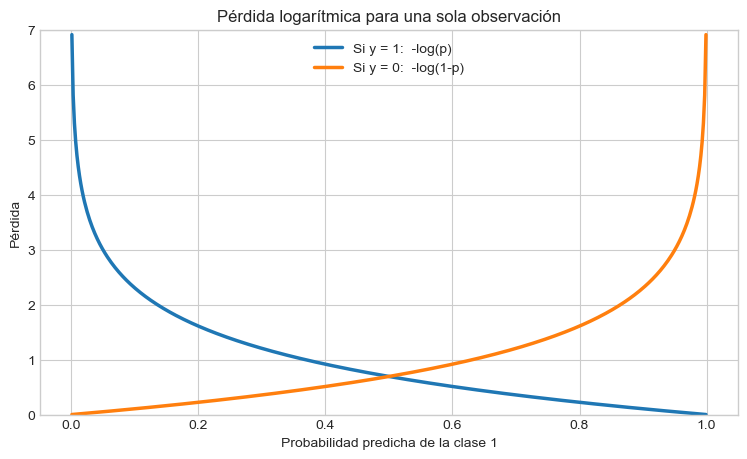

In [4]:
p = np.linspace(0.001, 0.999, 500)
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p, loss_y1, label="Si y = 1:  -log(p)", linewidth=2.5)
ax.plot(p, loss_y0, label="Si y = 0:  -log(1-p)", linewidth=2.5)
ax.set_title("Pérdida logarítmica para una sola observación")
ax.set_xlabel("Probabilidad predicha de la clase 1")
ax.set_ylabel("Pérdida")
ax.set_ylim(0, 7)
ax.legend()
plt.show()


## **6. Comparación rápida contra error cuadrático**

Podríamos intentar medir el error como:

$$
(y_i - \hat p_i)^2
$$

Eso funciona como una medida descriptiva, pero no sale naturalmente de una Bernoulli al aplicar máxima verosimilitud.

Además, la log loss castiga más fuerte los errores con alta confianza.

Por ejemplo, si la clase real es $1$:

- predecir $\hat p = 0.49$ está mal, pero no es catastrófico
- predecir $\hat p = 0.01$ significa estar casi seguro de la clase incorrecta


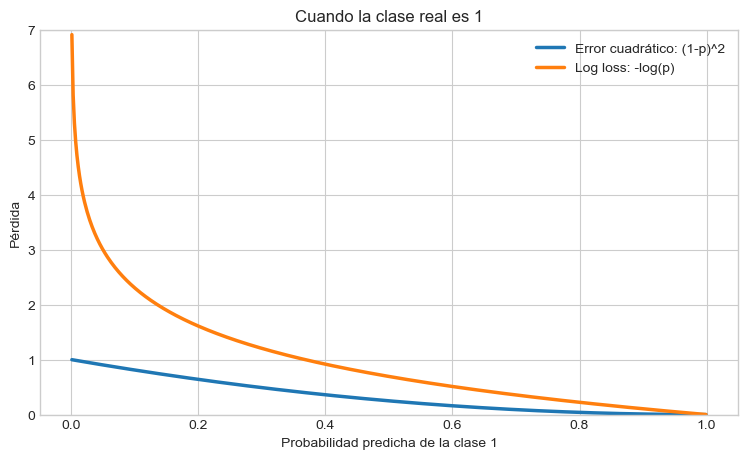

In [5]:
p = np.linspace(0.001, 0.999, 500)
y_real = 1
mse = (y_real - p) ** 2
logloss = -np.log(p)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p, mse, label="Error cuadrático: (1-p)^2", linewidth=2.5)
ax.plot(p, logloss, label="Log loss: -log(p)", linewidth=2.5)
ax.set_title("Cuando la clase real es 1")
ax.set_xlabel("Probabilidad predicha de la clase 1")
ax.set_ylabel("Pérdida")
ax.set_ylim(0, 7)
ax.legend()
plt.show()


## **7. La conexión con regresión logística**

En regresión logística modelamos la probabilidad como:

$$
\hat p_i = \sigma(z_i)
$$

Donde:

$$
z_i = \beta_0 + \beta_1x_{i1} + \cdots + \beta_kx_{ik}
$$

Y la función sigmoide es:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

La sigmoide convierte cualquier número real en una probabilidad entre $0$ y $1$.


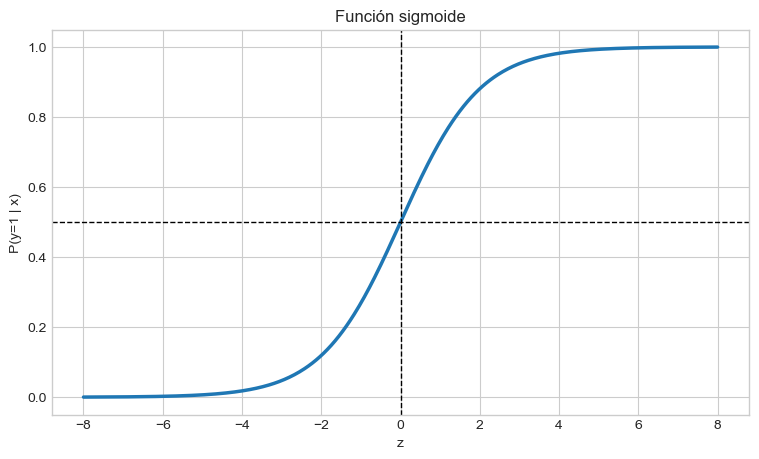

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 500)
p = sigmoid(z)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z, p, linewidth=2.5)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Función sigmoide")
ax.set_xlabel("z")
ax.set_ylabel("P(y=1 | x)")
plt.show()


## **8. Entrenar regresión logística equivale a minimizar log loss**

Para cada observación hacemos dos pasos:

1. Calculamos un score lineal:

$$
z_i = \beta^T x_i
$$

2. Convertimos ese score en probabilidad:

$$
\hat p_i = \sigma(z_i)
$$

Luego buscamos los parámetros $\beta$ que minimicen:

$$
-\frac{1}{n}\sum_{i=1}^{n} \left[y_i\log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right]
$$

Por eso se dice que la regresión logística no se entrena minimizando error cuadrático, sino minimizando una pérdida basada en la verosimilitud de una Bernoulli.


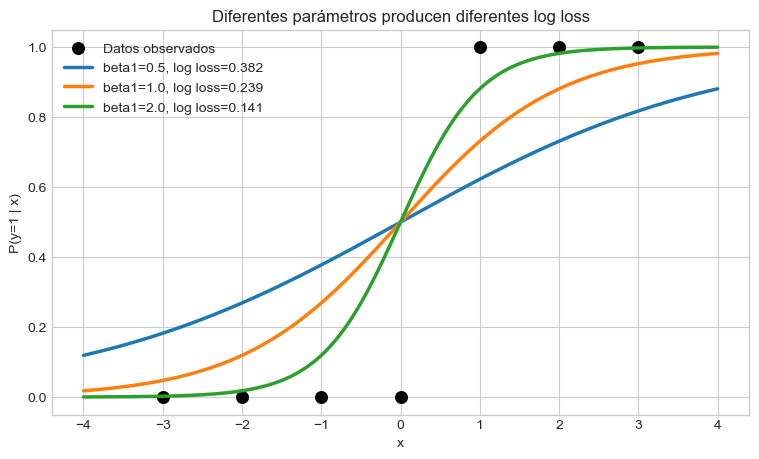

In [7]:
# Dataset miniatura de ejemplo
x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = np.array([0, 0, 0, 0, 1, 1, 1])

betas = [0.5, 1.0, 2.0]
beta0 = 0

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, color="black", s=70, label="Datos observados")

xx = np.linspace(-4, 4, 300)
for beta1 in betas:
    pp = sigmoid(beta0 + beta1 * xx)
    pred = sigmoid(beta0 + beta1 * x)
    loss = log_loss_manual(y, pred)
    ax.plot(xx, pp, linewidth=2.5, label=f"beta1={beta1}, log loss={loss:.3f}")

ax.set_title("Diferentes parámetros producen diferentes log loss")
ax.set_xlabel("x")
ax.set_ylabel("P(y=1 | x)")
ax.legend()
plt.show()


## **9. Versión binomial agrupada**

A veces no observamos datos individuo por individuo, sino conteos.

Por ejemplo, para un grupo con $n$ personas:

- $m$ personas tienen resultado $1$
- $n-m$ personas tienen resultado $0$

Entonces usamos una distribución **binomial**:

$$
P(M=m) = \binom{n}{m}p^m(1-p)^{n-m}
$$

La log-verosimilitud es:

$$
\log(L) = \log\binom{n}{m} + m\log(p) + (n-m)\log(1-p)
$$

El término $\log\binom{n}{m}$ no depende de $p$, así que para optimizar podemos ignorarlo.

Queda:

$$
m\log(p) + (n-m)\log(1-p)
$$

Que es exactamente la misma estructura que sumar Bernoullis individuales.


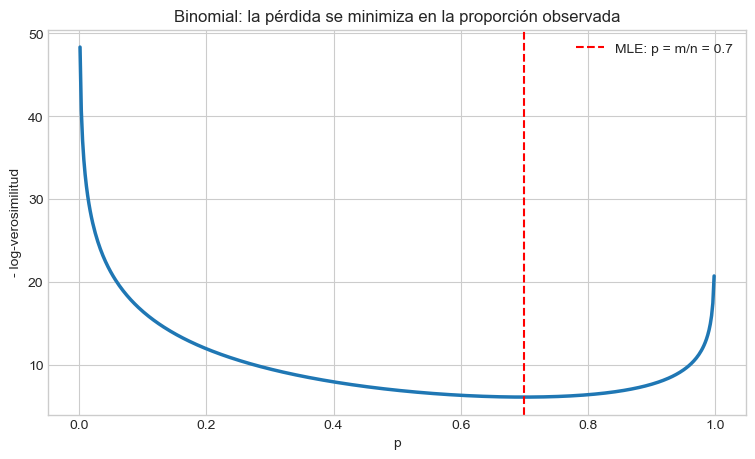

In [8]:
# Supongamos un grupo de 10 personas: 7 éxitos y 3 fracasos
n = 10
m = 7
p_grid = np.linspace(0.001, 0.999, 500)

log_verosimilitud = m * np.log(p_grid) + (n - m) * np.log(1 - p_grid)
neg_log_verosimilitud = -log_verosimilitud

p_mle = m / n

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p_grid, neg_log_verosimilitud, linewidth=2.5)
ax.axvline(p_mle, color="red", linestyle="--", label=f"MLE: p = m/n = {p_mle:.1f}")
ax.set_title("Binomial: la pérdida se minimiza en la proporción observada")
ax.set_xlabel("p")
ax.set_ylabel("- log-verosimilitud")
ax.legend()
plt.show()


## **10. Resumen para clase**

La cadena de ideas es:

$$
y \in \{0,1\}
$$

$$
Y \sim Bernoulli(p)
$$

$$
P(Y=y)=p^y(1-p)^{1-y}
$$

$$
L=\prod_{i=1}^{n}\hat p_i^{y_i}(1-\hat p_i)^{1-y_i}
$$

$$
\log(L)=\sum_{i=1}^{n}\left[y_i\log(\hat p_i)+(1-y_i)\log(1-\hat p_i)\right]
$$

$$
\text{Log Loss}=-\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat p_i)+(1-y_i)\log(1-\hat p_i)\right]
$$

**Conclusión:** si el resultado es binario, la log loss no es una ocurrencia arbitraria. Es la función de pérdida que aparece al aplicar máxima verosimilitud a una variable Bernoulli/binomial.


## **Ejercicios sugeridos**

1. Calcula manualmente la log loss para:

$$
y = [1, 0, 1]
$$

$$
\hat p = [0.8, 0.4, 0.6]
$$

2. ¿Qué pasa con la log loss si una observación tiene $y=1$ pero el modelo predice $\hat p=0.001$?

3. En el ejemplo binomial, cambia $m$ y $n$. Verifica que el mínimo ocurre en:

$$
\hat p = \frac{m}{n}
$$


In [9]:
# Espacio para resolver el ejercicio 1
